In [5]:
import os
import pandas as pd
import numpy as np
import re
from scipy.stats import gmean
from scipy import stats
import matplotlib.pyplot as plt


# Path to the working directory containing course materials
# os.chdir("Z:\\File folders\\Teaching\\Reproducible Research\\2023\\Repository\\RRcourse2023\\6. Coding and documentation")

# ---------------------------------------------------------------------------
# Load task data from O*NET (cross-walked from SOC to ISCO-08)
# Source: https://ibs.org.pl/en/resources/occupation-classifications-crosswalks-from-onet-soc-to-isco/
# Columns: isco08 (occupation code), t_* (task variables)
# ---------------------------------------------------------------------------
task_data = pd.read_csv("C:\\Users\\lenovo\\Desktop\\RR_Projects\\RRcourse2026\\Data\\onet_tasks.csv")

# ---------------------------------------------------------------------------
# Load Eurostat quarterly employment data by 1-digit ISCO-08 category
# Details: https://www.ilo.org/public/english/bureau/stat/isco/isco08/
# ---------------------------------------------------------------------------
ISCO_FILE = "C:\\Users\\lenovo\\Desktop\\RR_Projects\\RRcourse2026\\Data\\Eurostat_employment_isco.xlsx"
ISCO_SHEETS = range(1, 10)  # ISCO categories 1 through 9

isco = {
    i: pd.read_excel(ISCO_FILE, sheet_name=f"ISCO{i}")
    for i in ISCO_SHEETS
}

# ---------------------------------------------------------------------------
# Calculate total employed workers per country by summing across ISCO groups
# Extend COUNTRIES list to run the analysis for additional countries
# ---------------------------------------------------------------------------
COUNTRIES = ["Belgium", "Spain", "Poland"]

totals = {
    country: sum(isco[i][country] for i in ISCO_SHEETS)
    for country in COUNTRIES
}

In [6]:
# Add ISCO category label to each sheet before merging
for i in ISCO_SHEETS:
    isco[i]['ISCO'] = i

# Combine all ISCO groups into a single DataFrame
all_data = pd.concat(isco.values(), ignore_index=True)

# Tile the per-country totals across all 9 ISCO groups, then compute occupation shares
for country in COUNTRIES:
    all_data[f"total_{country}"] = pd.concat([totals[country]] * len(ISCO_SHEETS), ignore_index=True)
    all_data[f"share_{country}"] = all_data[country] / all_data[f"total_{country}"]

In [7]:
# Extract the 1-digit ISCO code from the full occupation code
task_data["isco08_1dig"] = task_data["isco08"].astype(str).str[:1].astype(int)

# Aggregate task values to 1-digit ISCO level (drop the original full code after grouping)
aggdata = task_data.groupby("isco08_1dig").mean().drop(columns=["isco08"])

# ---------------------------------------------------------------------------
# Task variables of interest (Non-routine cognitive analytical tasks)
# Based on Autor's task framework:
#   t_4A2a4  - Analyzing Data or Information
#   t_4A2b2  - Thinking Creatively
#   t_4A4a1  - Interpreting the Meaning of Information for Others
# ---------------------------------------------------------------------------
TASK_VARS = ["t_4A2a4", "t_4A2b2", "t_4A4a1"]

# Merge employment data with aggregated task intensities
combined = pd.merge(all_data, aggdata, left_on='ISCO', right_on='isco08_1dig', how='left')

# ---------------------------------------------------------------------------
# Standardise task values per country using employment-share weights
# (weighted mean = 0, weighted std. dev. = 1), separately for each country
# ---------------------------------------------------------------------------

In [8]:
def weighted_standardise(df, task, weight_col):
    """
    Standardise a task variable using employment-share weights.
    Computes weighted mean and std. dev., then returns z-scores.
    """
    mean = np.average(df[task], weights=df[weight_col])
    sd = np.sqrt(np.average((df[task] - mean) ** 2, weights=df[weight_col]))
    return (df[task] - mean) / sd


# Standardise each task variable for each country (weighted by occupation share)
for country in COUNTRIES:
    for task in TASK_VARS:
        combined[f"std_{country}_{task}"] = weighted_standardise(
            combined, task, f"share_{country}"
        )

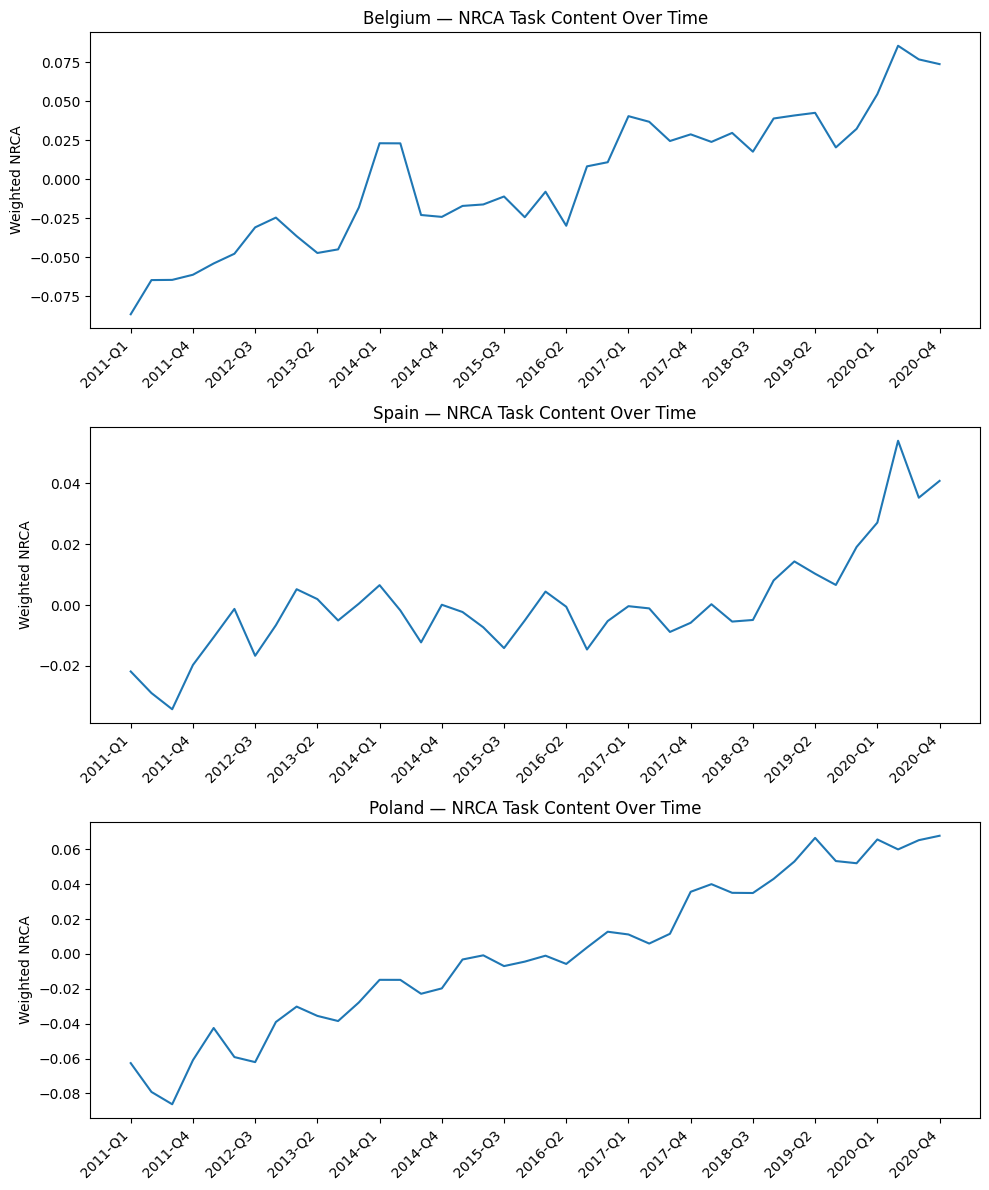

In [9]:
# ---------------------------------------------------------------------------
# Non-Routine Cognitive Analytical (NRCA) task content intensity
# Defined by Acemoglu & Autor as the sum of standardised task scores:
#   t_4A2a4, t_4A2b2, t_4A4a1
# ---------------------------------------------------------------------------

# Step 1: Sum standardised task scores into a composite NRCA index per country
for country in COUNTRIES:
    combined[f"{country}_NRCA"] = sum(
        combined[f"std_{country}_{task}"] for task in TASK_VARS
    )

# Step 2: Standardise the NRCA index using employment-share weights
for country in COUNTRIES:
    combined[f"std_{country}_NRCA"] = weighted_standardise(
        combined, f"{country}_NRCA", f"share_{country}"
    )

# Step 3: Compute weighted country-level NRCA mean over time
#         (multiply standardised NRCA by occupation share, then sum by period)
agg = {}
for country in COUNTRIES:
    combined[f"multip_{country}_NRCA"] = (
        combined[f"std_{country}_NRCA"] * combined[f"share_{country}"]
    )
    agg[country] = (
        combined.groupby("TIME")[f"multip_{country}_NRCA"].sum().reset_index()
    )

# Step 4: Plot NRCA trends for all countries in a single figure
fig, axes = plt.subplots(len(COUNTRIES), 1, figsize=(10, 4 * len(COUNTRIES)), sharex=False)

for ax, country in zip(axes, COUNTRIES):
    data = agg[country]
    ax.plot(data["TIME"], data[f"multip_{country}_NRCA"])
    ax.set_title(f"{country} — NRCA Task Content Over Time")
    ax.set_xticks(range(0, len(data), 3))
    ax.set_xticklabels(data["TIME"][::3], rotation=45, ha="right")
    ax.set_ylabel("Weighted NRCA")

plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------------
# To extend this analysis, update COUNTRIES and/or TASK_VARS at the top.
# Example — Routine Manual (RM) tasks (Acemoglu & Autor):
#   t_4A3a3   - Controlling Machines and Processes
#   t_4C2d1i  - Spend Time Making Repetitive Motions
#   t_4C3d3   - Pace Determined by Speed of Equipment
# ---------------------------------------------------------------------------